# Cu–Ag from EMT

This notebook walks through using ASE's EMT calculator together with the
`AsePhase` wrapper to feed a binary alloy into landau:

1. build five FCC supercells along the Cu–Ag composition axis,
2. compute static energies (with atomic relaxation) and a phonon DOS for each,
3. wrap each composition as an `AsePhase` (via `CrystalThermo`), combine them in
   a `FastInterpolatingPhase`, and hand the result to `calc_phase_diagram`.

EMT is a generic empirical potential, not parametrised against Cu–Ag
thermochemistry, so the numerical values are illustrative — the point is the
**workflow**, not a quantitative phase diagram for this system.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import trapezoid

from ase.build import bulk
from ase.calculators.emt import EMT
from ase.optimize import BFGS
from ase.phonons import Phonons
from ase.thermochemistry import CrystalThermo

from landau.phases.asewrapper import AsePhase
from landau.phases import FastInterpolatingPhase
from landau.interpolate import RedlichKister
from landau.calculate import calc_phase_diagram
from landau.plot import plot_phase_diagram

rng = np.random.default_rng(42)


## 1  Build Cu–Ag supercells

We sample $x_{\mathrm{Cu}} \in \{0, 0.25, 0.5, 0.75, 1\}$ in a $2\times 2\times 2$
supercell of the conventional FCC cell (32 atoms), placing Cu atoms at random sites with a
fixed RNG seed.  The lattice constant follows Vegard's law,

$$a(x_{\mathrm{Cu}}) = (1-x_{\mathrm{Cu}})\,a_{\mathrm{Ag}} + x_{\mathrm{Cu}}\,a_{\mathrm{Cu}}.$$

Random 32-atom occupancies are not formal SQS structures, but they break the on-site
force cancellations of small ordered cells so atomic relaxation actually does something
(see the next section).


In [2]:
a_cu = 3.61  # Å
a_ag = 4.09  # Å

def make_cell(x_cu, n=2):
    """n^3 conventional FCC cells (4*n^3 atoms) randomly populated to the
    requested Cu fraction, with Vegard's-law lattice constant."""
    a = (1 - x_cu) * a_ag + x_cu * a_cu
    cell = bulk('Cu', 'fcc', a=a, cubic=True).repeat((n, n, n))
    N = len(cell)
    n_cu = int(round(N * x_cu))
    syms = ['Ag'] * N
    for i in rng.permutation(N)[:n_cu]:
        syms[i] = 'Cu'
    cell.set_chemical_symbols(syms)
    return cell

compositions = [0.0, 0.25, 0.5, 0.75, 1.0]
cells = {x: make_cell(x) for x in compositions}
for x, c in cells.items():
    n_cu = sum(s == 'Cu' for s in c.get_chemical_symbols())
    a_conv = (1 - x) * a_ag + x * a_cu  # conventional FCC lattice constant
    print(f'x_Cu = {x:.2f}  N = {len(c):2d}  ({n_cu} Cu, {len(c)-n_cu} Ag)  a = {a_conv:.3f} Å')


x_Cu = 0.00  N = 32  (0 Cu, 32 Ag)  a = 4.090 Å
x_Cu = 0.25  N = 32  (8 Cu, 24 Ag)  a = 3.970 Å
x_Cu = 0.50  N = 32  (16 Cu, 16 Ag)  a = 3.850 Å
x_Cu = 0.75  N = 32  (24 Cu, 8 Ag)  a = 3.730 Å
x_Cu = 1.00  N = 32  (32 Cu, 0 Ag)  a = 3.610 Å


## 2  Static EMT energies and mixing enthalpy

Random Cu placements on the ideal FCC lattice carry residual forces that bias the static
mixing enthalpy upwards.  We **relax atomic positions** with BFGS at fixed cell shape
before recording the static energy, and compare unrelaxed vs. relaxed mixing enthalpies
below.

$$\Delta H_{\mathrm{mix}}(x_{\mathrm{Cu}}) = E(x_{\mathrm{Cu}})
    - (1-x_{\mathrm{Cu}})\,E_{\mathrm{Ag}} - x_{\mathrm{Cu}}\,E_{\mathrm{Cu}}.$$

Pure endpoints are unaffected by relaxation (single-species perfect FCC), so the curve
anchors at zero on both ends.

(Note: random 32-atom configurations are not statistically converged toward the true
random-alloy mixing enthalpy; SQS with larger cells is the standard cure.  The pedagogical
point here is the workflow.)


x_Cu=0.00  E_mix unrelaxed =   0.00  relaxed =   0.00  meV/atom
x_Cu=0.25  E_mix unrelaxed =  42.04  relaxed =  28.35  meV/atom
x_Cu=0.50  E_mix unrelaxed =  62.75  relaxed =  40.44  meV/atom
x_Cu=0.75  E_mix unrelaxed =  37.75  relaxed =  25.81  meV/atom
x_Cu=1.00  E_mix unrelaxed =   0.00  relaxed =   0.00  meV/atom


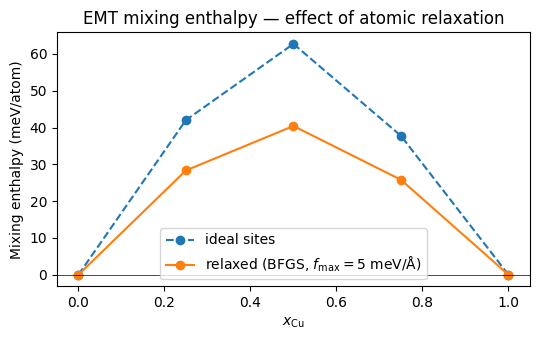

In [3]:
E_unrelaxed = {}
E0 = {}
for x, c in cells.items():
    c.calc = EMT()
    E_unrelaxed[x] = c.get_potential_energy() / len(c)
    BFGS(c, logfile=None).run(fmax=5e-3, steps=200)
    E0[x] = c.get_potential_energy() / len(c)

E_ag, E_cu = E0[0.0], E0[1.0]
xs = np.array(compositions)
E_vals = np.array([E0[x] for x in compositions])
E_vals_un = np.array([E_unrelaxed[x] for x in compositions])
E_mix = E_vals - ((1 - xs) * E_ag + xs * E_cu)
E_mix_un = E_vals_un - ((1 - xs) * E_unrelaxed[0.0] + xs * E_unrelaxed[1.0])

fig, ax = plt.subplots(figsize=(5.5, 3.5))
ax.plot(xs, E_mix_un * 1000, 'o--', label='ideal sites')
ax.plot(xs, E_mix * 1000, 'o-', label='relaxed (BFGS, $f_{\\max} = 5$ meV/Å)')
ax.axhline(0, color='k', lw=0.5)
ax.set_xlabel(r'$x_{\mathrm{Cu}}$')
ax.set_ylabel('Mixing enthalpy (meV/atom)')
ax.set_title('EMT mixing enthalpy — effect of atomic relaxation')
ax.legend()
plt.tight_layout()

for x in compositions:
    print(f'x_Cu={x:.2f}  E_mix unrelaxed = {(E_unrelaxed[x] - ((1-x)*E_unrelaxed[0.0] + x*E_unrelaxed[1.0]))*1000:6.2f}  '
          f'relaxed = {(E0[x] - ((1-x)*E_ag + x*E_cu))*1000:6.2f}  meV/atom')


## 3  Phonon DOS at each composition

We compute the EMT phonon DOS on the **relaxed** cells (`ase.phonons.Phonons` with finite
displacements and a $2\times 2\times 2$ supercell of the 32-atom cell).  Imaginary modes —
which the random configurations would otherwise develop, especially without the position
relaxation above — are discarded by setting `xmin=0.0` on the grid sampling.


x_Cu = 0.00  ω_max = 22.1 meV


x_Cu = 0.25  ω_max = 27.0 meV


x_Cu = 0.50  ω_max = 30.5 meV


x_Cu = 0.75  ω_max = 33.0 meV


x_Cu = 1.00  ω_max = 34.7 meV


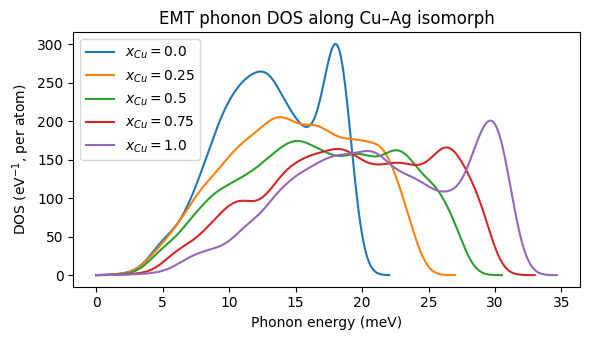

In [4]:
dos_data = {}  # x_Cu -> (omega, dos_per_atom)

for x, cell in cells.items():
    name = f'cuag-{int(x*100):03d}-phonon'
    ph = Phonons(cell, EMT(), supercell=(2, 2, 2), delta=0.05, name=name)
    ph.run()
    ph.read(acoustic=True)
    raw = ph.get_dos(kpts=(10, 10, 10), verbose=False)
    g = raw.sample_grid(npts=300, xmin=0.0, width=0.0008)
    omega = g.get_energies()
    weights = g.get_weights()
    # normalise to 3 modes/atom (imaginary modes outside [0, omega_max] were dropped)
    weights = weights * 3.0 * len(cell) / trapezoid(weights, omega)
    dos_data[x] = (omega, weights / len(cell))
    print(f'x_Cu = {x:.2f}  ω_max = {omega.max()*1e3:.1f} meV')

fig, ax = plt.subplots(figsize=(6, 3.5))
for x, (om, ws) in dos_data.items():
    ax.plot(om * 1e3, ws, label=f'$x_{{Cu}}={x}$')
ax.set_xlabel('Phonon energy (meV)')
ax.set_ylabel('DOS (eV$^{-1}$, per atom)')
ax.set_title('EMT phonon DOS along Cu–Ag isomorph')
ax.legend()
plt.tight_layout()


## 4  Build `AsePhase` line phases and the solution model

Each sampled composition becomes an `AsePhase` carrying a `CrystalThermo` with its
static energy and phonon DOS.  Combining several `AsePhase` line phases in a
`FastInterpolatingPhase` with a Redlich–Kister interpolator gives a binary solution
model whose free energy is interpolated between the sampled compositions, with the
ideal configurational mixing entropy added on top (`add_entropy=True`).


In [5]:
line_phases = []
for x in compositions:
    omega, dos = dos_data[x]
    ct = CrystalThermo(
        phonon_DOS=dos,
        phonon_energies=omega,
        formula_units=1,
        potentialenergy=E0[x],
    )
    line_phases.append(
        AsePhase(
            name=f'FCC x_Cu={x}',
            fixed_concentration=x,
            thermochem=ct,
        )
    )

fcc = FastInterpolatingPhase(
    name='FCC(Cu,Ag)',
    phases=line_phases,
    add_entropy=True,
    interpolator=RedlichKister(3),
)


## 5  Phase diagram

`calc_phase_diagram` samples $(T, \mu)$ on a grid, and `refine=True` traces the
binodal wherever the interpolated free-energy curve develops a region of negative
curvature.  `plot_phase_diagram` then renders the result.


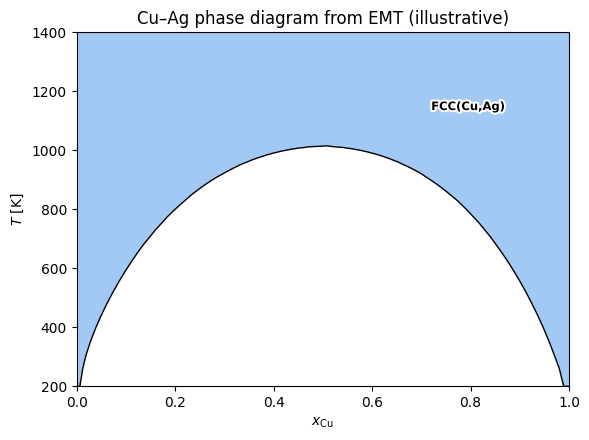

In [6]:
Ts = np.linspace(200, 1400, 40)
mu = np.linspace(-0.08, 0.08, 120)
df = calc_phase_diagram([fcc], Ts=Ts, mu=mu, refine=True)

fig, ax = plt.subplots(figsize=(6, 4.5))
plot_phase_diagram(df, ax=ax, triplepoints=True)
ax.set_xlabel(r'$x_{\mathrm{Cu}}$')
ax.set_title('Cu–Ag phase diagram from EMT (illustrative)')
plt.tight_layout()


## Summary

* `AsePhase` lets any `ase.thermochemistry` object enter landau as a fixed-composition
  line phase; combining several of them in a `FastInterpolatingPhase` with
  `add_entropy=True` yields a binary solution model.
* `calc_phase_diagram(..., refine=True)` traces the resulting binodal, which
  `plot_phase_diagram` renders as a two-phase region.
* For a quantitative Cu–Ag diagram, replace EMT with a Cu–Ag-aware potential
  (EAM, ML-FF) or DFT-derived phonons; the structure of this notebook is unchanged.
